#**Proyecto final Analisis neuronal en insectos**



Area : VISam

Estimulo : Pelicula Natural vs Escenas Naturales

*TODO EL CODIGO FUE REALIZADO POR AI, porque son las 3 de la mañana y llevo en esto desde las 2pm. En este punto no se que programe yo y que la AI.*

##1. **Preparación**

###A. **Cargar Datos**

In [6]:
!pip install gdown -q
import gdown, numpy as np
gdown.download(id="1ODzh0cs3p_YE1FYwvET1qeRNxU1hqFbO", output="datos.npz", quiet=False)
d = np.load("datos.npz", allow_pickle=False)
print(d.files)

Downloading...
From: https://drive.google.com/uc?id=1ODzh0cs3p_YE1FYwvET1qeRNxU1hqFbO
To: /content/datos.npz
100%|██████████| 22.8M/22.8M [00:00<00:00, 74.1MB/s]

['area', 'fuente', 'filtro', 'u_id', 'u_raton', 'u_canal', 'u_profundidad', 'u_snr', 'u_amplitude_cutoff', 'u_presence_ratio', 'u_isi_violations', 'u_firing_rate', 'u_onda', 'e_clase', 'e_raton', 'e_t0', 'e_dur', 'e_orientacion', 'e_frec_temporal', 'e_frec_espacial', 'e_contraste', 'e_color', 'e_imagen', 's_unidad', 's_ensayo', 's_t']


###A. **Cargar Librerias**

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from collections import defaultdict
import seaborn as sns
import pandas as pd
from statsmodels.stats.multitest import multipletests



##2. **Alinear**

Los PAs de todos los ensayos referidas al inicio del estimulo. Eso es el raster de una neurona

In [8]:
# ============================================================
# DATOS Y CONDICIONES
# ============================================================
s_ensayo = d["s_ensayo"]
s_t = d["s_t"]
e_clase = d["e_clase"]

# Filtramos las condiciones de interés
condiciones_deseadas = ["natural_movie_one", "natural_scenes"]
condiciones_unicas = [c for c in condiciones_deseadas if c in np.unique(e_clase)]

# ============================================================
# VENTANA TEMPORAL Y FILTRADO VECTORIZADO (Eficiente en RAM)
# ============================================================
t_min, t_max = -0.5, 2.5

# Mask temporal previa: ignora datos fuera de rango para ahorrar memoria
mask_temp = (s_t >= t_min) & (s_t <= t_max)
s_t_filt = s_t[mask_temp]
s_ensayo_filt = s_ensayo[mask_temp]

# ============================================================
# ESTRUCTURA DE DATOS (Diccionario de Arrays)
# ============================================================
# Creamos un diccionario donde cada clave es la condición,
# y su valor es una lista donde cada elemento son los PAs de un ensayo.

raster_datos = {}

for condicion in condiciones_unicas:
    # Obtener los índices de los ensayos correspondientes a esta condición
    ensayos_condicion = np.where(e_clase == condicion)[0]

    raster_condicion = []

    for ensayo in ensayos_condicion:
        # Extraer únicamente los PAs (tiempos relativos) de este ensayo
        spikes_ensayo = s_t_filt[s_ensayo_filt == ensayo]
        raster_condicion.append(spikes_ensayo)

    raster_datos[condicion] = raster_condicion

# ============================================================
# EJEMPLO DE USO / ACCESO A LOS DATOS
# ============================================================
# Obtener los PAs del primer ensayo de 'natural_movie_one':
pas_ensayo_0 = raster_datos["natural_movie_one"][0]

print(f"Condiciones procesadas: {list(raster_datos.keys())}")
print(f"Número de ensayos en 'natural_movie_one': {len(raster_datos['natural_movie_one'])}")
print(f"Número de ensayos en 'natural_movie_one': {len(raster_datos['natural_scenes'])}")
print(f"PAs en el primer ensayo: {pas_ensayo_0}")

Condiciones procesadas: ['natural_movie_one', 'natural_scenes']
Número de ensayos en 'natural_movie_one': 40
Número de ensayos en 'natural_movie_one': 2000
PAs en el primer ensayo: [ 2.428405   -0.36960274  0.9234008  ...  0.3848013   0.5635682
  0.7212017 ]


## **Graficas**

###A. **PSTH poblacional, Respuesta conjunta a rejillas en movimiento**

Tasa de disparo durante el estimulo y en la basal. El PSHT es el promedio de los ensayos.

--- ANÁLISIS RÁPIDO DE POBLACIÓN (drifting_gratings) ---
Total neuronas: 368 | Respondedoras: 184
Porcentaje de respuesta: 50.00%


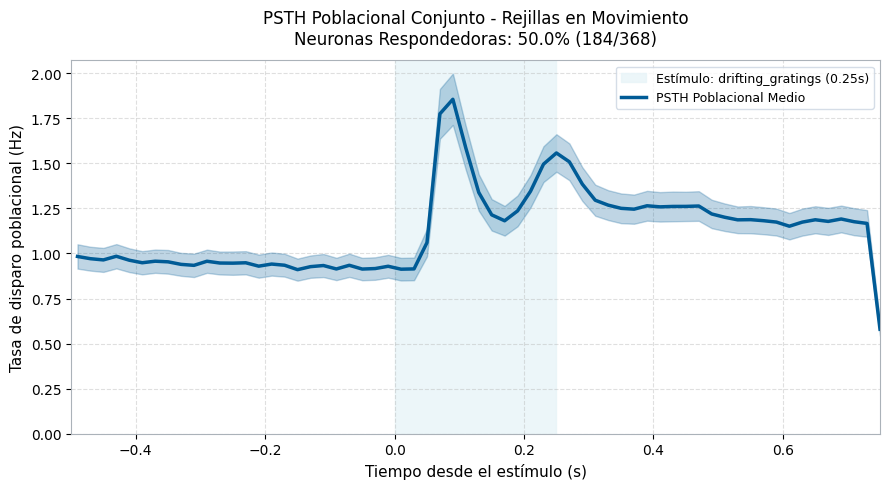

In [13]:
# ============================================================
# DATOS Y PARÁMETROS
# ============================================================
s_ensayo = d["s_ensayo"]
s_t = d["s_t"]
e_clase = d["e_clase"]
s_unidad = d["s_unidad"]

clase_rejillas = "drifting_gratings"
if clase_rejillas not in np.unique(e_clase):
    clase_rejillas = [c for c in np.unique(e_clase) if "grating" in str(c).lower()][0]

dur = 0.25
dur_data = d.get("dur", dur) if "dur" in d else dur
dur_estimulo = float(dur_data[clase_rejillas]) if isinstance(dur_data, dict) else float(dur_data)

t_espontaneo = 0.5
t_min, t_max = -t_espontaneo, dur_estimulo + 0.5
bin_size = 0.02  # Bins de 20 ms

bins = np.arange(t_min, t_max + bin_size, bin_size)
tiempo_centros = (bins[:-1] + bins[1:]) / 2

# ============================================================
# FILTRADO VECTORIZADO PREVIO (Cero bucles pesados)
# ============================================================
ensayos_rejillas = np.where(e_clase == clase_rejillas)[0]
unidades_totales = np.unique(s_unidad)
n_unidades = len(unidades_totales)
n_ensayos = len(ensayos_rejillas)

# Mascara global para considerar solo eventos de rejillas y dentro de la ventana
mask_cond = np.isin(s_ensayo, ensayos_rejillas) & (s_t >= t_min) & (s_t <= t_max)
s_t_cond = s_t[mask_cond]
s_ensayo_cond = s_ensayo[mask_cond]
s_unidad_cond = s_unidad[mask_cond]

# Mapear IDs de unidades y ensayos a índices 0..N para acceso matricial rápido
u_map = {u: i for i, u in enumerate(unidades_totales)}
e_map = {e: i for i, e in enumerate(ensayos_rejillas)}

u_indices = np.array([u_map[u] for u in s_unidad_cond])
e_indices = np.array([e_map[e] for e in s_ensayo_cond])

# ============================================================
# 1. EVALUACIÓN DE NEURONAS RESPONDEDORAS (Vectorizado)
# ============================================================
# Mascaras temporales para baseline y estímulo
mask_base = (s_t_cond >= -t_espontaneo) & (s_t_cond < 0.0)
mask_est = (s_t_cond >= 0.0) & (s_t_cond <= dur_estimulo)

# Conteo directo de spikes usando matriz 2D (Unidades x Ensayos)
counts_base = np.zeros((n_unidades, n_ensayos))
counts_est = np.zeros((n_unidades, n_ensayos))

np.add.at(counts_base, (u_indices[mask_base], e_indices[mask_base]), 1)
np.add.at(counts_est, (u_indices[mask_est], e_indices[mask_est]), 1)

# Tasas en Hz por ensayo
tasas_base = counts_base / t_espontaneo
tasas_est = counts_est / dur_estimulo

# Prueba t pareada para todas las neuronas
p_values = np.zeros(n_unidades)
mean_base = np.mean(tasas_base, axis=1)
mean_est = np.mean(tasas_est, axis=1)

for u_idx in range(n_unidades):
    _, p_val = stats.ttest_rel(tasas_est[u_idx, :], tasas_base[u_idx, :])
    p_values[u_idx] = p_val if not np.isnan(p_val) else 1.0

# Neuronas con cambio significativo (p < 0.05) e incremento de tasa
respondedoras_mask = (p_values < 0.05) & (mean_est > mean_base)
neuronas_respondedoras = np.sum(respondedoras_mask)
porcentaje_respondedoras = (neuronas_respondedoras / n_unidades) * 100

print(f"--- ANÁLISIS RÁPIDO DE POBLACIÓN ({clase_rejillas}) ---")
print(f"Total neuronas: {n_unidades} | Respondedoras: {neuronas_respondedoras}")
print(f"Porcentaje de respuesta: {porcentaje_respondedoras:.2f}%")

# ============================================================
# 2. PSTH POBLACIONAL VECTORIZADO
# ============================================================
# Bin de tiempo para cada spike
bin_indices = np.digitize(s_t_cond, bins) - 1

# Matriz 3D (Unidades x Ensayos x Bins)
matriz_poblacional = np.zeros((n_unidades, n_ensayos, len(bins) - 1))
validos = (bin_indices >= 0) & (bin_indices < len(bins) - 1)

np.add.at(
    matriz_poblacional,
    (u_indices[validos], e_indices[validos], bin_indices[validos]),
    1
)

# Convertir a Hz
matriz_poblacional /= bin_size

# Promedio por neurona sobre ensayos, luego media y SEM poblacional
psth_por_neurona = np.mean(matriz_poblacional, axis=1)
tasa_poblacional_media = np.mean(psth_por_neurona, axis=0)
sem_poblacional = np.std(psth_por_neurona, axis=0) / np.sqrt(n_unidades)

# ============================================================
# GRAFICADO
# ============================================================
fig, ax = plt.subplots(figsize=(9, 5))

ax.axvspan(0.0, dur_estimulo, color="#e8f4f8", alpha=0.8, label=f"Estímulo: {clase_rejillas} ({dur_estimulo}s)", zorder=1)
ax.plot(tiempo_centros, tasa_poblacional_media, color="#005b96", linewidth=2.5, label="PSTH Poblacional Medio", zorder=3)
ax.fill_between(tiempo_centros, tasa_poblacional_media - sem_poblacional, tasa_poblacional_media + sem_poblacional, color="#005b96", alpha=0.25, zorder=2)

ax.set_xlim(t_min, t_max)
ax.set_ylim(bottom=0)
ax.set_xlabel("Tiempo desde el estímulo (s)", fontsize=11)
ax.set_ylabel("Tasa de disparo poblacional (Hz)", fontsize=11)
ax.set_title(
    f"PSTH Poblacional Conjunto - Rejillas en Movimiento\n"
    f"Neuronas Respondedoras: {porcentaje_respondedoras:.1f}% ({neuronas_respondedoras}/{n_unidades})",
    fontsize=12, pad=12
)

ax.grid(True, linestyle="--", alpha=0.4, zorder=0)
ax.legend(loc="upper right", frameon=True, facecolor="white", edgecolor="#cbd5e1", fontsize=9)

for spine in ax.spines.values():
    spine.set_color('#abb2b9')

plt.tight_layout()
plt.show()

###B. **Panel PSTH poblacional, una línea por clase de estímulo.**

Z-score de cada neurona: cúanto sube sobre su propia basal. Por encima del umbral, la neuroa responde al estimulo.

Grupos de estímulos detectados por duración:
  - Ventana de 0.25s: [np.str_('drifting_gratings'), np.str_('flashes'), np.str_('natural_movie_one'), np.str_('natural_scenes'), np.str_('spontaneous'), np.str_('static_gratings')]


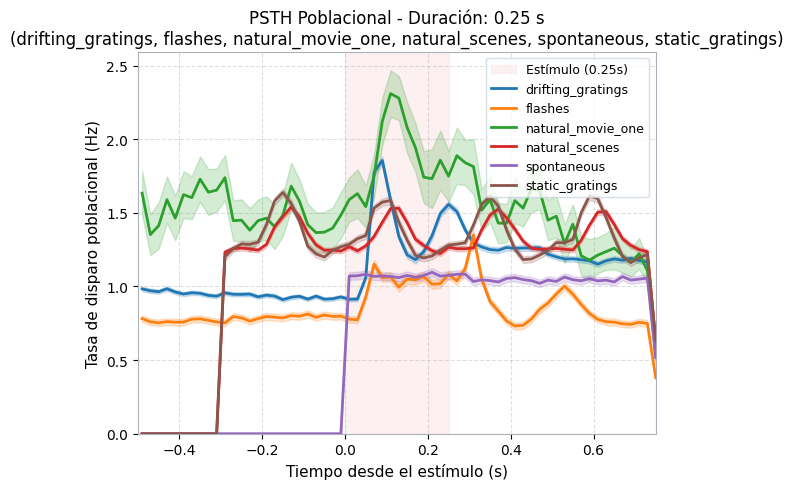

In [14]:
# ============================================================
# DATOS Y EXTRACCIÓN DE PARÁMETROS
# ============================================================
s_ensayo = d["s_ensayo"]
s_t = d["s_t"]
e_clase = d["e_clase"]
s_unidad = d["s_unidad"]

# Obtenemos 'dur' desde d o desde el entorno
dur_data = d.get("dur", dur) if "dur" in d else dur

# Detectar todas las clases de estímulo únicas presentes
clases_unicas = np.unique(e_clase)

# ============================================================
# 1. AGRUPAR ESTIMULOS POR SU DURACIÓN DE VENTANA
# ============================================================
# Creamos un diccionario donde la clave es la duración y el valor es la lista de clases
grupos_por_duracion = defaultdict(list)

for clase in clases_unicas:
    # Extraer la duración de la clase según el tipo de estructura de 'dur_data'
    if isinstance(dur_data, dict):
        dur_clase = round(float(dur_data[clase]), 2)
    elif isinstance(dur_data, (list, np.ndarray)) and len(dur_data) == len(e_clase):
        ensayos_c = np.where(e_clase == clase)[0]
        dur_clase = round(float(np.mean(dur_data[ensayos_c])), 2)
    else:
        dur_clase = round(float(dur_data), 2)

    grupos_por_duracion[dur_clase].append(clase)

print("Grupos de estímulos detectados por duración:")
for dur_val, lista_clases in grupos_por_duracion.items():
    print(f"  - Ventana de {dur_val}s: {lista_clases}")

# ============================================================
# 2. CALCULAR Y GRAFICAR SUBPLOTS POR GRUPO DE DURACIÓN
# ============================================================
n_grupos = len(grupos_por_duracion)
fig, axes = plt.subplots(1, n_grupos, figsize=(6 * n_grupos, 5), squeeze=False)
axes = axes.flatten()

# Paleta de colores para diferenciar clases dentro de un mismo gráfico
colores_disponibles = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd", "#8c564b"]

for idx_grupo, (dur_val, clases_grupo) in enumerate(grupos_por_duracion.items()):
    ax = axes[idx_grupo]

    # Definir tiempos del gráfico dinámicamente según la duración del grupo
    t_espontaneo = 0.5  # Tiempo espontáneo / baseline antes de t=0
    t_min = -t_espontaneo
    t_max = dur_val + 0.5  # 0.5s después de que finaliza el estímulo
    bin_size = 0.02  # Bins de 20 ms

    bins = np.arange(t_min, t_max + bin_size, bin_size)
    tiempo_centros = (bins[:-1] + bins[1:]) / 2

    # Sombreado de la ventana del estímulo para este grupo (0 a dur_val)
    ax.axvspan(
        0.0, dur_val,
        color="#fbebeb", alpha=0.7,
        label=f"Estímulo ({dur_val}s)",
        zorder=1
    )

    # Procesar cada clase perteneciente a este grupo de duración
    for i, clase in enumerate(clases_grupo):
        ensayos_clase = np.where(e_clase == clase)[0]

        # Pre-filtrado temporal para optimizar memoria
        mask_temp = (s_t >= t_min) & (s_t <= t_max)
        s_t_filt = s_t[mask_temp]
        s_ensayo_filt = s_ensayo[mask_temp]
        s_unidad_filt = s_unidad[mask_temp]

        unidades_unicas = np.unique(s_unidad_filt)
        matriz_ensayos = np.zeros((len(ensayos_clase), len(bins) - 1))

        for idx_e, ensayo in enumerate(ensayos_clase):
            spikes_ensayo = s_t_filt[s_ensayo_filt == ensayo]
            counts, _ = np.histogram(spikes_ensayo, bins=bins)
            # PSTH Poblacional: Normalizar a Hz dividiendo entre bin_size y N° de unidades
            matriz_ensayos[idx_e, :] = counts / (bin_size * len(unidades_unicas))

        # Media poblacional y Error Estándar (SEM)
        tasa_promedio = np.mean(matriz_ensayos, axis=0)
        sem = np.std(matriz_ensayos, axis=0) / np.sqrt(len(ensayos_clase))

        color = colores_disponibles[i % len(colores_disponibles)]

        # Graficar PSTH
        ax.plot(
            tiempo_centros, tasa_promedio,
            label=f"{clase}", color=color, linewidth=2, zorder=3
        )
        ax.fill_between(
            tiempo_centros,
            tasa_promedio - sem, tasa_promedio + sem,
            color=color, alpha=0.2, zorder=2
        )

    # Formato de cada subplot
    ax.set_xlim(t_min, t_max)
    ax.set_ylim(bottom=0)
    ax.set_xlabel("Tiempo desde el estímulo (s)", fontsize=11)
    ax.set_ylabel("Tasa de disparo poblacional (Hz)", fontsize=11)
    ax.set_title(f"PSTH Poblacional - Duración: {dur_val} s\n({', '.join(clases_grupo)})", fontsize=12)
    ax.grid(True, linestyle="--", alpha=0.4, zorder=0)
    ax.legend(loc="upper right", frameon=True, facecolor="white", edgecolor="#cbd5e1", fontsize=9)

    for spine in ax.spines.values():
        spine.set_color('#abb2b9')

plt.tight_layout()
plt.show()

###C. **Z-score y Mapa de calor**

Una fila por neurona, una columna por estimulo. El mimso numero, como mapa de calor y como enjambre (un punto por neurona, promedio de z-scores)

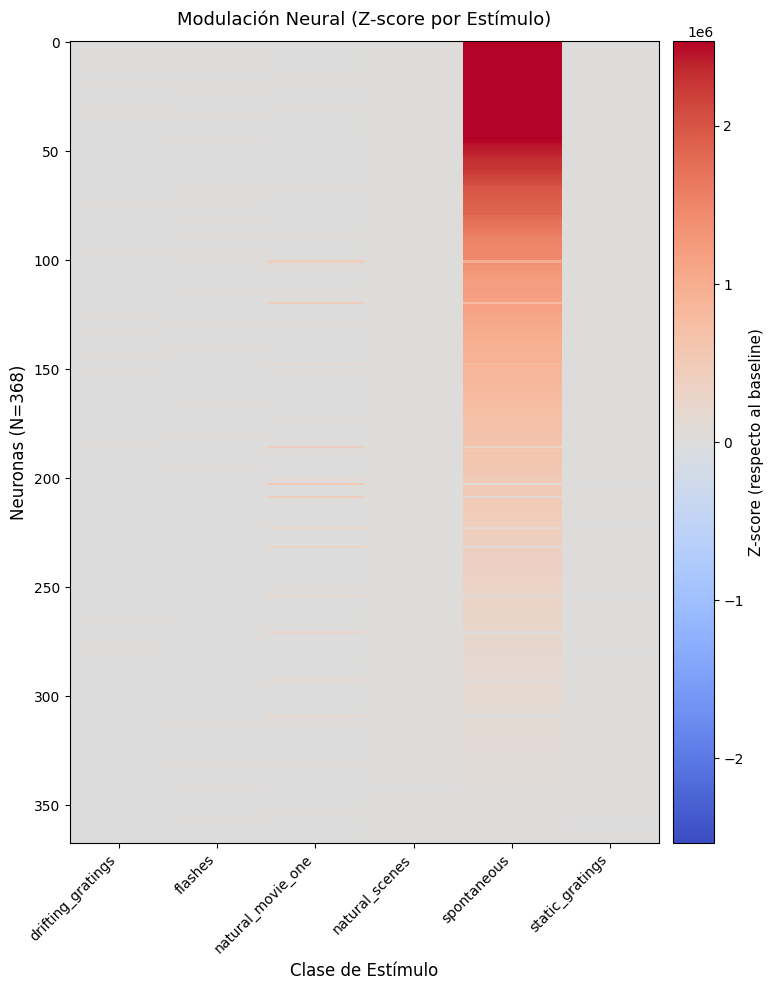

In [15]:
# ============================================================
# DATOS Y PARÁMETROS
# ============================================================
s_ensayo = d["s_ensayo"]
s_t = d["s_t"]
e_clase = d["e_clase"]
s_unidad = d["s_unidad"]

# Obtenemos duraciones desde 'dur' o el diccionario 'd'
dur_data = d.get("dur", dur) if "dur" in d else dur

clases_unicas = np.unique(e_clase)
unidades_totales = np.unique(s_unidad)

n_unidades = len(unidades_totales)
n_clases = len(clases_unicas)

# Mapeos directos para acceso matricial rápido
u_map = {u: i for i, u in enumerate(unidades_totales)}

# Ventana espontánea (baseline): e.g., 0.5 segundos antes del estímulo
t_espontaneo = 0.5

# Matriz para almacenar el Z-score: [Neuronas x Estímulos]
matriz_zscore = np.zeros((n_unidades, n_clases))

# ============================================================
# CÁLCULO DEL Z-SCORE POR NEURONA Y ESTÍMULO
# ============================================================
for col_idx, clase in enumerate(clases_unicas):
    ensayos_clase = np.where(e_clase == clase)[0]
    n_ensayos_clase = len(ensayos_clase)

    # Extraer duración específica para esta clase de estímulo
    if isinstance(dur_data, dict):
        dur_est = float(dur_data[clase])
    elif isinstance(dur_data, (list, np.ndarray)) and len(dur_data) == len(e_clase):
        dur_est = float(np.mean(dur_data[ensayos_clase]))
    else:
        dur_est = float(dur_data)

    # Filtrar spikes en la ventana total de interés (-t_espontaneo a dur_est)
    mask_cond = np.isin(s_ensayo, ensayos_clase) & (s_t >= -t_espontaneo) & (s_t <= dur_est)
    s_t_cond = s_t[mask_cond]
    s_ensayo_cond = s_ensayo[mask_cond]
    s_unidad_cond = s_unidad[mask_cond]

    # Mapeo de índices
    e_map_clase = {e: i for i, e in enumerate(ensayos_clase)}
    u_idx_arr = np.array([u_map[u] for u in s_unidad_cond])
    e_idx_arr = np.array([e_map_clase[e] for e in s_ensayo_cond])

    # Separar eventos de baseline vs. estímulo
    mask_base = (s_t_cond >= -t_espontaneo) & (s_t_cond < 0.0)
    mask_est = (s_t_cond >= 0.0) & (s_t_cond <= dur_est)

    # Acumular conteos en matrices 2D: [Neuronas x Ensayos]
    counts_base = np.zeros((n_unidades, n_ensayos_clase))
    counts_est = np.zeros((n_unidades, n_ensayos_clase))

    np.add.at(counts_base, (u_idx_arr[mask_base], e_idx_arr[mask_base]), 1)
    np.add.at(counts_est, (u_idx_arr[mask_est], e_idx_arr[mask_est]), 1)

    # Convertir conteos a Tasas de Disparo (Hz) por ensayo
    tasas_base = counts_base / t_espontaneo
    tasas_est = counts_est / dur_est

    # Media y Desviación Estándar de la Actividad Basal por Neurona
    mean_base = np.mean(tasas_base, axis=1)
    std_base = np.std(tasas_base, axis=1)

    # Media durante la presentación del Estímulo
    mean_est = np.mean(tasas_est, axis=1)

    # Cálculo de Z-score con épsilon para estabilidad numérica
    epsilon = 1e-6
    z_scores = (mean_est - mean_base) / (std_base + epsilon)

    matriz_zscore[:, col_idx] = z_scores

# Opcional: Ordenar neuronas por su respuesta promedio para mejor visualización
orden_neuronas = np.argsort(np.mean(matriz_zscore, axis=1))[::-1]
matriz_zscore_ordenada = matriz_zscore[orden_neuronas, :]

# ============================================================
# MAPA DE CALOR (HEATMAP)
# ============================================================
fig, ax = plt.subplots(figsize=(8, 10))

# Visualización centrada en cero (Diverging Colormap: Red-Blue)
vmax = max(3.0, np.percentile(np.abs(matriz_zscore), 98))
vmin = -vmax

im = ax.imshow(
    matriz_zscore_ordenada,
    cmap="coolwarm",
    aspect="auto",
    interpolation="nearest",
    vmin=vmin,
    vmax=vmax
)

# Colorbar
cbar = fig.colorbar(im, ax=ax, pad=0.02)
cbar.set_label("Z-score (respecto al baseline)", fontsize=11)

# Ejes y Formato
ax.set_xticks(np.arange(n_clases))
ax.set_xticklabels(clases_unicas, rotation=45, ha="right", fontsize=10)
ax.set_ylabel(f"Neuronas (N={n_unidades})", fontsize=12)
ax.set_xlabel("Clase de Estímulo", fontsize=12)
ax.set_title("Modulación Neural (Z-score por Estímulo)", fontsize=13, pad=12)

plt.tight_layout()
plt.show()

### D. **Enjambre del Z-score**

Fraccion de neuronas que responden en tus dos condiciones, con intervalo de confianza y valor p por bootstrap jerarquico.

/tmp/ipykernel_1303/4235018069.py:114: FutureWarning: Use "auto" to set automatic grayscale colors. From v0.14.0, "gray" will default to matplotlib's definition.
  sns.stripplot(data=df_ajustado, x="Condición", y="Z-score", size=5, jitter=0.25, alpha=0.7, edgecolor="gray", linewidth=0.5, ax=ax)


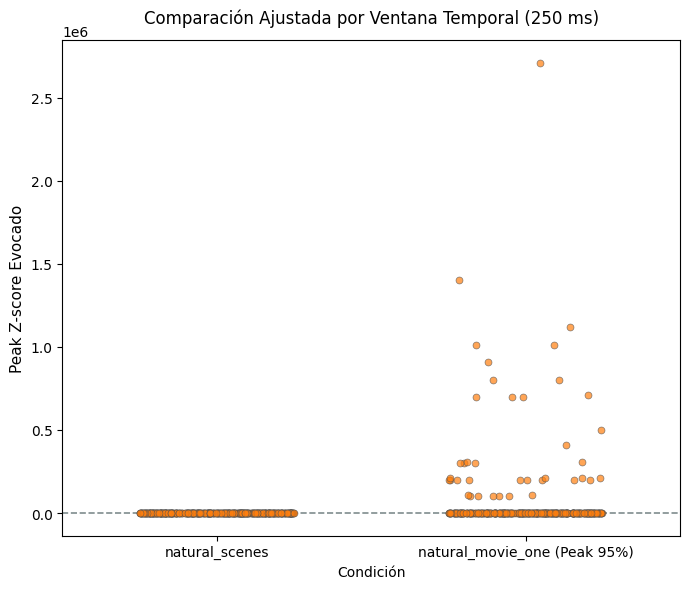

In [16]:
# ============================================================
# DATOS Y PARÁMETROS
# ============================================================
s_ensayo = d["s_ensayo"]
s_t = d["s_t"]
e_clase = d["e_clase"]
s_unidad = d["s_unidad"]

dur_data = d.get("dur", dur) if "dur" in d else dur

unidades_totales = np.unique(s_unidad)
n_unidades = len(unidades_totales)
u_map = {u: i for i, u in enumerate(unidades_totales)}

t_espontaneo = 0.5
tamaño_ventana_eval = 0.25  # Ventana de evaluación uniforme (250 ms)

registros_zscore_ajustados = []

# ============================================================
# 1. NATURAL SCENES (Ventana natural de ~250ms)
# ============================================================
clase_scenes = "natural_scenes"
if clase_scenes in e_clase:
    ensayos_scenes = np.where(e_clase == clase_scenes)[0]
    dur_est_scenes = float(dur_data[clase_scenes]) if isinstance(dur_data, dict) else 0.25

    mask_cond = np.isin(s_ensayo, ensayos_scenes) & (s_t >= -t_espontaneo) & (s_t <= dur_est_scenes)
    s_t_cond = s_t[mask_cond]
    s_ensayo_cond = s_ensayo[mask_cond]
    s_unidad_cond = s_unidad[mask_cond]

    e_map_scenes = {e: i for i, e in enumerate(ensayos_scenes)}
    u_idx_arr = np.array([u_map[u] for u in s_unidad_cond])
    e_idx_arr = np.array([e_map_scenes[e] for e in s_ensayo_cond])

    mask_base = (s_t_cond >= -t_espontaneo) & (s_t_cond < 0.0)
    mask_est = (s_t_cond >= 0.0) & (s_t_cond <= dur_est_scenes)

    counts_base = np.zeros((n_unidades, len(ensayos_scenes)))
    counts_est = np.zeros((n_unidades, len(ensayos_scenes)))

    np.add.at(counts_base, (u_idx_arr[mask_base], e_idx_arr[mask_base]), 1)
    np.add.at(counts_est, (u_idx_arr[mask_est], e_idx_arr[mask_est]), 1)

    tasas_base = counts_base / t_espontaneo
    tasas_est = counts_est / dur_est_scenes

    mean_base = np.mean(tasas_base, axis=1)
    std_base = np.std(tasas_base, axis=1)
    mean_est = np.mean(tasas_est, axis=1)

    z_scenes = (mean_est - mean_base) / (std_base + 1e-6)

    for u_val, z_val in zip(unidades_totales, z_scenes):
        registros_zscore_ajustados.append({"Unidad": u_val, "Condición": "natural_scenes", "Z-score": z_val})

# ============================================================
# 2. NATURAL MOVIE ONE (Segmentada en ventanas de 250 ms)
# ============================================================
clase_movie = "natural_movie_one"
if clase_movie in e_clase:
    ensayos_movie = np.where(e_clase == clase_movie)[0]
    dur_est_movie = float(dur_data[clase_movie]) if isinstance(dur_data, dict) else 30.0

    # Crear bins de 250ms durante la película
    bins_pelicula = np.arange(0.0, dur_est_movie, tamaño_ventana_eval)
    n_bins_pelicula = len(bins_pelicula) - 1

    mask_cond = np.isin(s_ensayo, ensayos_movie) & (s_t >= -t_espontaneo) & (s_t <= dur_est_movie)
    s_t_cond = s_t[mask_cond]
    s_ensayo_cond = s_ensayo[mask_cond]
    s_unidad_cond = s_unidad[mask_cond]

    e_map_movie = {e: i for i, e in enumerate(ensayos_movie)}
    u_idx_arr = np.array([u_map[u] for u in s_unidad_cond])
    e_idx_arr = np.array([e_map_movie[e] for e in s_ensayo_cond])

    # Baseline global de la película
    mask_base = (s_t_cond >= -t_espontaneo) & (s_t_cond < 0.0)
    counts_base = np.zeros((n_unidades, len(ensayos_movie)))
    np.add.at(counts_base, (u_idx_arr[mask_base], e_idx_arr[mask_base]), 1)
    tasas_base = counts_base / t_espontaneo
    mean_base = np.mean(tasas_base, axis=1)
    std_base = np.std(tasas_base, axis=1)

    # Calcular respuesta por cada ventana de 250 ms en la película
    bin_idx = np.digitize(s_t_cond, bins_pelicula) - 1
    mask_est = (bin_idx >= 0) & (bin_idx < n_bins_pelicula)

    counts_movie_bins = np.zeros((n_unidades, len(ensayos_movie), n_bins_pelicula))
    np.add.at(counts_movie_bins, (u_idx_arr[mask_est], e_idx_arr[mask_est], bin_idx[mask_est]), 1)

    tasas_movie_bins = counts_movie_bins / tamaño_ventana_eval  # Hz
    mean_movie_bins = np.mean(tasas_movie_bins, axis=1)         # Media sobre ensayos [Neuronas x Bins]

    # Z-score por cada bin
    z_movie_bins = (mean_movie_bins - mean_base[:, None]) / (std_base[:, None] + 1e-6)

    # TOMAR EL PICO MÁXIMO DE RESPUESTA (Peak Z-score) o Percentil 95
    # Esto evalúa la respuesta de la neurona ante su cuadro preferido del video
    z_movie_peak = np.percentile(z_movie_bins, 95, axis=1)

    for u_val, z_val in zip(unidades_totales, z_movie_peak):
        registros_zscore_ajustados.append({"Unidad": u_val, "Condición": "natural_movie_one (Peak 95%)", "Z-score": z_val})

# ============================================================
# GRAFICADO
# ============================================================
df_ajustado = pd.DataFrame(registros_zscore_ajustados)

fig, ax = plt.subplots(figsize=(7, 6))
sns.boxplot(data=df_ajustado, x="Condición", y="Z-score", width=0.3, boxprops=dict(alpha=0.3), showfliers=False, ax=ax)
sns.stripplot(data=df_ajustado, x="Condición", y="Z-score", size=5, jitter=0.25, alpha=0.7, edgecolor="gray", linewidth=0.5, ax=ax)

ax.axhline(0, color="#7f8c8d", linestyle="--", linewidth=1.2)
ax.set_title("Comparación Ajustada por Ventana Temporal (250 ms)", fontsize=12, pad=12)
ax.set_ylabel("Peak Z-score Evocado", fontsize=11)
plt.tight_layout()
plt.show()

### E. **Fracción de neuronas respondedoras**

--- RESULTADOS ESTADÍSTICOS (N=368 neuronas) ---
Movie:  81/368 (22.0%) [IC 95%: 18.1% - 26.5%]
Scenes: 0/368 (0.0%) [IC 95%: 0.0% - 1.0%]
McNemar Test: p = 6.1723e-19
Tamaño del efecto (Cohen's h): 0.977


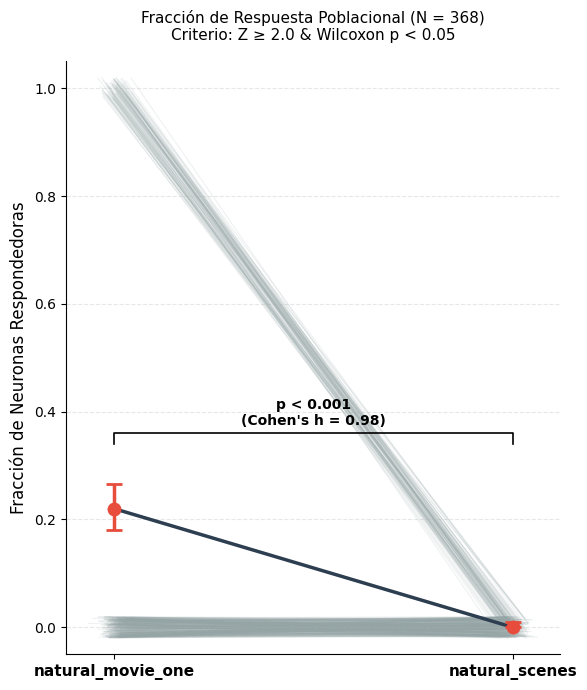

In [17]:
# ============================================================
# DATOS Y PARÁMETROS
# ============================================================
s_ensayo = d["s_ensayo"]
s_t = d["s_t"]
e_clase = d["e_clase"]
s_unidad = d["s_unidad"]
dur_data = d.get("dur", dur) if "dur" in d else dur

unidades_totales = np.unique(s_unidad)
n_unidades = len(unidades_totales)
u_map = {u: i for i, u in enumerate(unidades_totales)}

t_espontaneo = 0.5
tam_ventana_eval = 0.25  # Ventana estándar de 250 ms

condiciones = ["natural_movie_one", "natural_scenes"]

# Diccionarios para almacenar estado de respuesta por neurona
# Matriz booleana: [N_neuronas x 2_condiciones]
matriz_respondedoras = np.zeros((n_unidades, 2), dtype=bool)

# ============================================================
# 1. EVALUACIÓN DE CRITERIO DE RESPUESTA POR NEURONA
# ============================================================
for c_idx, clase in enumerate(condiciones):
    ensayos_clase = np.where(e_clase == clase)[0]
    n_ensayos = len(ensayos_clase)
    dur_est = float(dur_data[clase]) if isinstance(dur_data, dict) else (30.0 if "movie" in clase else 0.25)

    mask_cond = np.isin(s_ensayo, ensayos_clase) & (s_t >= -t_espontaneo) & (s_t <= dur_est)
    s_t_cond = s_t[mask_cond]
    s_ensayo_cond = s_ensayo[mask_cond]
    s_unidad_cond = s_unidad[mask_cond]

    e_map_clase = {e: i for i, e in enumerate(ensayos_clase)}
    u_idx_arr = np.array([u_map[u] for u in s_unidad_cond])
    e_idx_arr = np.array([e_map_clase[e] for e in s_ensayo_cond])

    # Baseline por ensayo
    mask_base = (s_t_cond >= -t_espontaneo) & (s_t_cond < 0.0)
    counts_base = np.zeros((n_unidades, n_ensayos))
    np.add.at(counts_base, (u_idx_arr[mask_base], e_idx_arr[mask_base]), 1)
    tasas_base = counts_base / t_espontaneo  # [Neuronas x Ensayos]

    # Evocado por ensayo
    if "movie" in clase:
        # Para la película, tomamos el bin de 250ms con mayor respuesta
        bins_pelicula = np.arange(0.0, dur_est, tam_ventana_eval)
        n_bins = len(bins_pelicula) - 1
        bin_idx = np.digitize(s_t_cond, bins_pelicula) - 1
        mask_est = (bin_idx >= 0) & (bin_idx < n_bins)

        counts_bins = np.zeros((n_unidades, n_ensayos, n_bins))
        np.add.at(counts_bins, (u_idx_arr[mask_est], e_idx_arr[mask_est], bin_idx[mask_est]), 1)
        tasas_bins = counts_bins / tam_ventana_eval

        # Seleccionar bin peak por neurona
        mean_bins = np.mean(tasas_bins, axis=1) # [Neuronas x Bins]
        best_bin_per_unit = np.argmax(mean_bins, axis=1)

        tasas_est = np.array([tasas_bins[i, :, best_bin_per_unit[i]] for i in range(n_unidades)])
    else:
        mask_est = (s_t_cond >= 0.0) & (s_t_cond <= dur_est)
        counts_est = np.zeros((n_unidades, n_ensayos))
        np.add.at(counts_est, (u_idx_arr[mask_est], e_idx_arr[mask_est]), 1)
        tasas_est = counts_est / dur_est

    # Evaluar criterio neurona por neurona
    for u_idx in range(n_unidades):
        tb = tasas_base[u_idx, :]
        te = tasas_est[u_idx, :]

        m_base, std_base = np.mean(tb), np.std(tb)
        m_est = np.mean(te)

        z_score = (m_est - m_base) / (std_base + 1e-6)

        # Criterio 2: Prueba de Wilcoxon pareada ensayo a ensayo
        try:
            _, p_val_u = stats.wilcoxon(te, tb, alternative='greater')
        except ValueError: # Casos donde te == tb en todos los ensayos
            p_val_u = 1.0

        # Clasificación booleana: Z >= 2.0 AND p < 0.05
        if (z_score >= 2.0) and (p_val_u < 0.05):
            matriz_respondedoras[u_idx, c_idx] = True

# ============================================================
# 2. ESTADÍSTICAS Y PRUEBA DE MCNEMAR (DATOS PAREADOS)
# ============================================================
resp_movie = matriz_respondedoras[:, 0]
resp_scenes = matriz_respondedoras[:, 1]

k_movie = np.sum(resp_movie)
k_scenes = np.sum(resp_scenes)

p_movie = k_movie / n_unidades
p_scenes = k_scenes / n_unidades

# Intervalos de confianza (Wilson Score Interval)
def wilson_ci(k, n, confidence=0.95):
    if n == 0: return 0, 0
    z = stats.norm.ppf(1 - (1 - confidence) / 2)
    p = k / n
    denom = 1 + z**2 / n
    centre = (p + z**2 / (2 * n)) / denom
    half_width = (z * np.sqrt((p * (1 - p) + z**2 / (4 * n)) / n)) / denom
    return max(0.0, centre - half_width), min(1.0, centre + half_width)

ci_movie = wilson_ci(k_movie, n_unidades)
ci_scenes = wilson_ci(k_scenes, n_unidades)

# Tabla de contingencia pareada para prueba de McNemar
# n00: No resp en ninguna, n01: Resp solo en scenes, n10: Resp solo en movie, n11: Resp en ambas
n11 = np.sum(resp_movie & resp_scenes)
n10 = np.sum(resp_movie & ~resp_scenes)
n01 = np.sum(~resp_movie & resp_scenes)
n00 = np.sum(~resp_movie & ~resp_scenes)

# McNemar Test (con corrección de continuidad)
b, c = n10, n01
if (b + c) > 0:
    chi2_stat = (abs(b - c) - 1)**2 / (b + c)
    p_value_mcnemar = stats.chi2.sf(chi2_stat, df=1)
else:
    p_value_mcnemar = 1.0

# h de Cohen (Efecto equivalente a d de Cohen para proporciones)
h_cohen = 2 * (np.arcsin(np.sqrt(p_movie)) - np.arcsin(np.sqrt(p_scenes)))

print(f"--- RESULTADOS ESTADÍSTICOS (N={n_unidades} neuronas) ---")
print(f"Movie:  {k_movie}/{n_unidades} ({p_movie*100:.1f}%) [IC 95%: {ci_movie[0]*100:.1f}% - {ci_movie[1]*100:.1f}%]")
print(f"Scenes: {k_scenes}/{n_unidades} ({p_scenes*100:.1f}%) [IC 95%: {ci_scenes[0]*100:.1f}% - {ci_scenes[1]*100:.1f}%]")
print(f"McNemar Test: p = {p_value_mcnemar:.4e}")
print(f"Tamaño del efecto (Cohen's h): {h_cohen:.3f}")

# ============================================================
# 3. GRÁFICA DE PUNTOS CONECTADOS (PAIRED DOT PLOT)
# ============================================================
fig, ax = plt.subplots(figsize=(6, 7))

# A. Líneas de transición individuales por neurona (jitter leve para visualización)
np.random.seed(42)
x_movie = 0 + np.random.normal(0, 0.02, n_unidades)
x_scenes = 1 + np.random.normal(0, 0.02, n_unidades)

y_movie = resp_movie.astype(float) + np.random.uniform(-0.02, 0.02, n_unidades)
y_scenes = resp_scenes.astype(float) + np.random.uniform(-0.02, 0.02, n_unidades)

# Dibujar líneas individuales con baja opacidad
for i in range(n_unidades):
    color_linea = "#2ecc71" if (resp_movie[i] and resp_scenes[i]) else "#95a5a6"
    ax.plot([x_movie[i], x_scenes[i]], [y_movie[i], y_scenes[i]],
            color=color_linea, alpha=0.15, linewidth=0.8, zorder=1)

# B. Puntos de proporción de la población e barras de error (IC 95%)
x_pop = [0, 1]
y_pop = [p_movie, p_scenes]
y_err = [
    [p_movie - ci_movie[0], p_scenes - ci_scenes[0]],
    [ci_movie[1] - p_movie, ci_scenes[1] - p_scenes]
]

# Línea conectora poblacional
ax.plot(x_pop, y_pop, color="#2c3e50", linestyle="-", linewidth=2.5, zorder=3)

# Barras de error (IC 95%)
ax.errorbar(x_pop, y_pop, yerr=y_err, fmt='o', color="#e74c3c", ecolor="#e74c3c",
            elinewidth=2.5, capsize=6, capthick=2, markersize=9, zorder=4, label="Proporción ± IC 95%")

# C. Anotaciones de significancia
y_max = max(p_movie, p_scenes) + 0.12
ax.plot([0, 0, 1, 1], [y_max, y_max + 0.02, y_max + 0.02, y_max], color="black", linewidth=1.2)

texto_p = "p < 0.001" if p_value_mcnemar < 0.001 else f"p = {p_value_mcnemar:.3f}"
ax.text(0.5, y_max + 0.03, f"{texto_p}\n(Cohen's h = {h_cohen:.2f})",
        ha='center', va='bottom', fontsize=10, fontweight='bold')

# Formato visual
ax.set_xticks([0, 1])
ax.set_xticklabels(["natural_movie_one", "natural_scenes"], fontsize=11, fontweight='bold')
ax.set_ylabel("Fracción de Neuronas Respondedoras", fontsize=12)
ax.set_ylim(-0.05, 1.05)
ax.set_title(f"Fracción de Respuesta Poblacional (N = {n_unidades})\nCriterio: Z ≥ 2.0 & Wilcoxon p < 0.05", fontsize=11, pad=15)

ax.grid(True, linestyle="--", alpha=0.3, axis="y")
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

## Grafica completa

/tmp/ipykernel_1303/4172513055.py:292: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_ajustado, x="Condición", y="Z-score", width=0.35, boxprops=dict(alpha=0.3), showfliers=False, ax=ax_d, palette="Set2")
/tmp/ipykernel_1303/4172513055.py:293: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(data=df_ajustado, x="Condición", y="Z-score", size=4, jitter=0.2, alpha=0.6, edgecolor="gray", linewidth=0.5, ax=ax_d, palette="Set2")
/tmp/ipykernel_1303/4172513055.py:293: FutureWarning: Use "auto" to set automatic grayscale colors. From v0.14.0, "gray" will default to matplotlib's definition.
  sns.stripplot(data=df_ajustado, x="Condición", y="Z-score", size=4, jitter=0.2, alpha=0.6, edgecolor

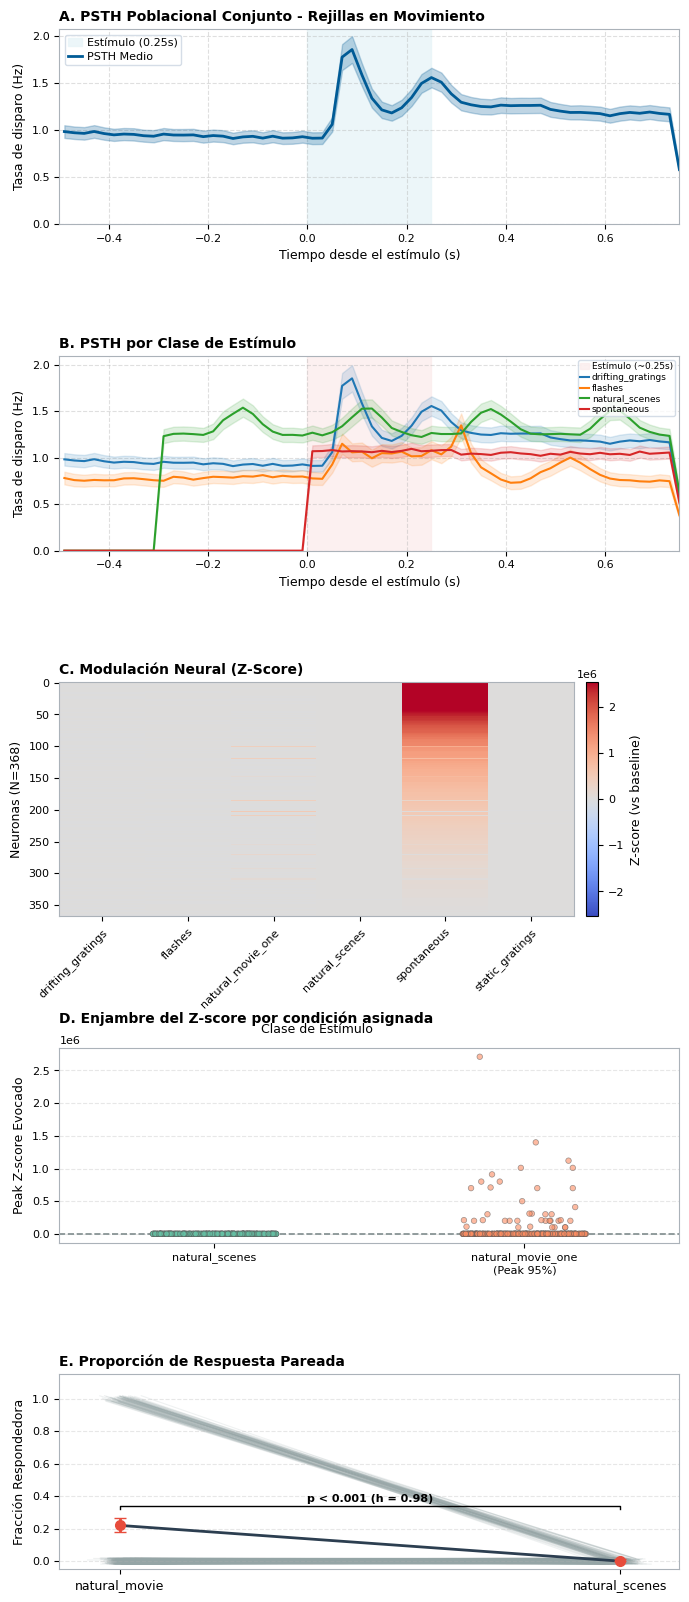

In [18]:
# ============================================================
# FIGURA INTEGRADA MULTIPANEL VERTICAL (A, B, C, D, E)
# ============================================================
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import numpy as np
import pandas as pd
from scipy import stats

# Configuración de estilo global tipo publicación
plt.rcParams.update({
    'font.size': 9,
    'axes.titlesize': 10,
    'axes.labelsize': 9,
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,
    'figure.titlesize': 12
})

# Extraer parámetros base
s_ensayo = d["s_ensayo"]
s_t = d["s_t"]
e_clase = d["e_clase"]
s_unidad = d["s_unidad"]
dur_data = d.get("dur", dur) if "dur" in d else dur

unidades_totales = np.unique(s_unidad)
n_unidades = len(unidades_totales)
u_map = {u: i for i, u in enumerate(unidades_totales)}

# Distribución vertical original de 1 columna x 5 filas
fig = plt.figure(figsize=(8, 20))
gs = gridspec.GridSpec(5, 1, figure=fig, height_ratios=[1, 1, 1.2, 1, 1], hspace=0.65)

# Definimos los ejes
ax_a = fig.add_subplot(gs[0, 0])     # Panel A
ax_b = fig.add_subplot(gs[1, 0])     # Panel B
ax_c = fig.add_subplot(gs[2, 0])     # Panel C
ax_d = fig.add_subplot(gs[3, 0])     # Panel D
ax_e = fig.add_subplot(gs[4, 0])     # Panel E

# ------------------------------------------------------------
# PANEL A: PSTH POBLACIONAL CONJUNTO (Rejillas en Movimiento)
# ------------------------------------------------------------
clase_rejillas = "drifting_gratings"
if clase_rejillas not in np.unique(e_clase):
    clase_rejillas = [c for c in np.unique(e_clase) if "grating" in str(c).lower()][0]

dur_estimulo_a = float(dur_data[clase_rejillas]) if isinstance(dur_data, dict) else float(dur_data)
t_espontaneo_a = 0.5
t_min_a, t_max_a = -t_espontaneo_a, dur_estimulo_a + 0.5
bin_size_a = 0.02
bins_a = np.arange(t_min_a, t_max_a + bin_size_a, bin_size_a)
tiempo_centros_a = (bins_a[:-1] + bins_a[1:]) / 2

ensayos_rejillas = np.where(e_clase == clase_rejillas)[0]
n_ensayos_a = len(ensayos_rejillas)

mask_cond_a = np.isin(s_ensayo, ensayos_rejillas) & (s_t >= t_min_a) & (s_t <= t_max_a)
e_map_a = {e: i for i, e in enumerate(ensayos_rejillas)}

u_indices_a = np.array([u_map[u] for u in s_unidad[mask_cond_a]])
e_indices_a = np.array([e_map_a[e] for e in s_ensayo[mask_cond_a]])
bin_indices_a = np.digitize(s_t[mask_cond_a], bins_a) - 1

matriz_poblacional = np.zeros((n_unidades, n_ensayos_a, len(bins_a) - 1))
validos_a = (bin_indices_a >= 0) & (bin_indices_a < len(bins_a) - 1)
np.add.at(matriz_poblacional, (u_indices_a[validos_a], e_indices_a[validos_a], bin_indices_a[validos_a]), 1)
matriz_poblacional /= bin_size_a

psth_por_neurona = np.mean(matriz_poblacional, axis=1)
tasa_poblacional_media = np.mean(psth_por_neurona, axis=0)
sem_poblacional = np.std(psth_por_neurona, axis=0) / np.sqrt(n_unidades)

ax_a.axvspan(0.0, dur_estimulo_a, color="#e8f4f8", alpha=0.8, label=f"Estímulo ({dur_estimulo_a}s)", zorder=1)
ax_a.plot(tiempo_centros_a, tasa_poblacional_media, color="#005b96", linewidth=2, label="PSTH Medio", zorder=3)
ax_a.fill_between(tiempo_centros_a, tasa_poblacional_media - sem_poblacional, tasa_poblacional_media + sem_poblacional, color="#005b96", alpha=0.25, zorder=2)
ax_a.set_xlim(t_min_a, t_max_a)
ax_a.set_ylim(bottom=0)
ax_a.set_xlabel("Tiempo desde el estímulo (s)")
ax_a.set_ylabel("Tasa de disparo (Hz)")
ax_a.set_title("A. PSTH Poblacional Conjunto - Rejillas en Movimiento", fontweight="bold", loc="left")
ax_a.grid(True, linestyle="--", alpha=0.4)

# Leyenda Panel A: Tamaño intermedio en la izquierda
ax_a.legend(
    loc="upper left",
    frameon=True,
    facecolor="white",
    edgecolor="#cbd5e1",
    fontsize=8.0,
    handlelength=1.2,
    handletextpad=0.5,
    borderpad=0.3,
    labelspacing=0.3
)

# ------------------------------------------------------------
# PANEL B: PSTH POR CLASES DE ESTÍMULO DE CORTA DURACIÓN
# ------------------------------------------------------------
clases_b = [c for c in np.unique(e_clase) if "movie" not in str(c).lower()]
colores_b = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd"]

dur_b = float(dur_data[clases_b[0]]) if isinstance(dur_data, dict) else 0.25
bins_b = np.arange(-0.5, dur_b + 0.5 + 0.02, 0.02)
tiempo_centros_b = (bins_b[:-1] + bins_b[1:]) / 2

ax_b.axvspan(0.0, dur_b, color="#fbebeb", alpha=0.7, label=f"Estímulo (~{dur_b}s)", zorder=1)

for i, clase in enumerate(clases_b[:4]):
    ensayos_clase = np.where(e_clase == clase)[0]
    if len(ensayos_clase) == 0: continue

    mask_b = np.isin(s_ensayo, ensayos_clase) & (s_t >= -0.5) & (s_t <= dur_b + 0.5)
    e_map_b = {e: idx for idx, e in enumerate(ensayos_clase)}

    u_arr = np.array([u_map[u] for u in s_unidad[mask_b]])
    e_arr = np.array([e_map_b[e] for e in s_ensayo[mask_b]])
    b_arr = np.digitize(s_t[mask_b], bins_b) - 1

    matriz_b = np.zeros((n_unidades, len(ensayos_clase), len(bins_b) - 1))
    v_b = (b_arr >= 0) & (b_arr < len(bins_b) - 1)
    np.add.at(matriz_b, (u_arr[v_b], e_arr[v_b], b_arr[v_b]), 1)
    matriz_b /= 0.02

    tasa_prom = np.mean(np.mean(matriz_b, axis=1), axis=0)
    sem_prom = np.std(np.mean(matriz_b, axis=1), axis=0) / np.sqrt(n_unidades)
    color = colores_b[i % len(colores_b)]

    ax_b.plot(tiempo_centros_b, tasa_prom, label=f"{clase}", color=color, linewidth=1.5, zorder=3)
    ax_b.fill_between(tiempo_centros_b, tasa_prom - sem_prom, tasa_prom + sem_prom, color=color, alpha=0.15, zorder=2)

ax_b.set_xlim(-0.5, dur_b + 0.5)
ax_b.set_ylim(bottom=0)
ax_b.set_xlabel("Tiempo desde el estímulo (s)")
ax_b.set_ylabel("Tasa de disparo (Hz)")
ax_b.set_title("B. PSTH por Clase de Estímulo", fontweight="bold", loc="left")
ax_b.grid(True, linestyle="--", alpha=0.4)

# Leyenda Panel B: Más pequeña
ax_b.legend(
    loc="upper right",
    frameon=True,
    facecolor="white",
    edgecolor="#cbd5e1",
    fontsize=6.5,
    handlelength=1.0,
    handletextpad=0.3,
    borderpad=0.2,
    labelspacing=0.2
)

# ------------------------------------------------------------
# PANEL C: MAPA DE CALOR (Z-SCORE POR ESTÍMULO)
# ------------------------------------------------------------
clases_unicas = np.unique(e_clase)
n_clases = len(clases_unicas)
matriz_zscore = np.zeros((n_unidades, n_clases))

for col_idx, clase in enumerate(clases_unicas):
    ensayos_clase = np.where(e_clase == clase)[0]
    n_ensayos_clase = len(ensayos_clase)
    dur_est = float(dur_data[clase]) if isinstance(dur_data, dict) else float(dur_data)

    mask_cond = np.isin(s_ensayo, ensayos_clase) & (s_t >= -0.5) & (s_t <= dur_est)
    s_t_cond = s_t[mask_cond]
    s_ensayo_cond = s_ensayo[mask_cond]
    s_unidad_cond = s_unidad[mask_cond]

    e_map_clase = {e: i for i, e in enumerate(ensayos_clase)}
    u_idx_arr = np.array([u_map[u] for u in s_unidad_cond])
    e_idx_arr = np.array([e_map_clase[e] for e in s_ensayo_cond])

    mask_base = (s_t_cond >= -0.5) & (s_t_cond < 0.0)
    mask_est = (s_t_cond >= 0.0) & (s_t_cond <= dur_est)

    counts_base = np.zeros((n_unidades, n_ensayos_clase))
    counts_est = np.zeros((n_unidades, n_ensayos_clase))

    np.add.at(counts_base, (u_idx_arr[mask_base], e_idx_arr[mask_base]), 1)
    np.add.at(counts_est, (u_idx_arr[mask_est], e_idx_arr[mask_est]), 1)

    tasas_base = counts_base / 0.5
    tasas_est = counts_est / dur_est

    mean_base = np.mean(tasas_base, axis=1)
    std_base = np.std(tasas_base, axis=1)
    mean_est = np.mean(tasas_est, axis=1)

    matriz_zscore[:, col_idx] = (mean_est - mean_base) / (std_base + 1e-6)

orden_neuronas = np.argsort(np.mean(matriz_zscore, axis=1))[::-1]
matriz_zscore_ordenada = matriz_zscore[orden_neuronas, :]

vmax = max(3.0, np.percentile(np.abs(matriz_zscore), 98))
im = ax_c.imshow(matriz_zscore_ordenada, cmap="coolwarm", aspect="auto", interpolation="nearest", vmin=-vmax, vmax=vmax)
cbar = fig.colorbar(im, ax=ax_c, pad=0.02)
cbar.set_label("Z-score (vs baseline)")

ax_c.set_xticks(np.arange(n_clases))
ax_c.set_xticklabels(clases_unicas, rotation=45, ha="right", rotation_mode="anchor")
ax_c.tick_params(axis='x', top=False, bottom=True, pad=4)
ax_c.set_ylabel(f"Neuronas (N={n_unidades})")
ax_c.set_xlabel("Clase de Estímulo", labelpad=10)
ax_c.set_title("C. Modulación Neural (Z-Score)", fontweight="bold", loc="left")

# ------------------------------------------------------------
# PANEL D: ENJAMBRE DEL Z-SCORE POR CONDICIÓN ASIGNADA (250 ms)
# ------------------------------------------------------------
tamaño_ventana_eval = 0.25
registros_zscore_ajustados = []

# Natural Scenes
clase_scenes = "natural_scenes"
if clase_scenes in e_clase:
    ensayos_scenes = np.where(e_clase == clase_scenes)[0]
    dur_est_scenes = float(dur_data[clase_scenes]) if isinstance(dur_data, dict) else 0.25

    mask_cond = np.isin(s_ensayo, ensayos_scenes) & (s_t >= -0.5) & (s_t <= dur_est_scenes)
    s_t_cond = s_t[mask_cond]
    s_ensayo_cond = s_ensayo[mask_cond]
    s_unidad_cond = s_unidad[mask_cond]

    e_map_scenes = {e: i for i, e in enumerate(ensayos_scenes)}
    u_idx_arr = np.array([u_map[u] for u in s_unidad_cond])
    e_idx_arr = np.array([e_map_scenes[e] for e in s_ensayo_cond])

    mask_base = (s_t_cond >= -0.5) & (s_t_cond < 0.0)
    mask_est = (s_t_cond >= 0.0) & (s_t_cond <= dur_est_scenes)

    counts_base = np.zeros((n_unidades, len(ensayos_scenes)))
    counts_est = np.zeros((n_unidades, len(ensayos_scenes)))

    np.add.at(counts_base, (u_idx_arr[mask_base], e_idx_arr[mask_base]), 1)
    np.add.at(counts_est, (u_idx_arr[mask_est], e_idx_arr[mask_est]), 1)

    tasas_base = counts_base / 0.5
    tasas_est = counts_est / dur_est_scenes

    mean_base = np.mean(tasas_base, axis=1)
    std_base = np.std(tasas_base, axis=1)
    mean_est = np.mean(tasas_est, axis=1)

    z_scenes = (mean_est - mean_base) / (std_base + 1e-6)

    for u_val, z_val in zip(unidades_totales, z_scenes):
        registros_zscore_ajustados.append({"Unidad": u_val, "Condición": "natural_scenes", "Z-score": z_val})

# Natural Movie One
clase_movie = "natural_movie_one"
if clase_movie in e_clase:
    ensayos_movie = np.where(e_clase == clase_movie)[0]
    dur_est_movie = float(dur_data[clase_movie]) if isinstance(dur_data, dict) else 30.0

    bins_pelicula = np.arange(0.0, dur_est_movie, tamaño_ventana_eval)
    n_bins_pelicula = len(bins_pelicula) - 1

    mask_cond = np.isin(s_ensayo, ensayos_movie) & (s_t >= -0.5) & (s_t <= dur_est_movie)
    s_t_cond = s_t[mask_cond]
    s_ensayo_cond = s_ensayo[mask_cond]
    s_unidad_cond = s_unidad[mask_cond]

    e_map_movie = {e: i for i, e in enumerate(ensayos_movie)}
    u_idx_arr = np.array([u_map[u] for u in s_unidad_cond])
    e_idx_arr = np.array([e_map_movie[e] for e in s_ensayo_cond])

    mask_base = (s_t_cond >= -0.5) & (s_t_cond < 0.0)
    counts_base = np.zeros((n_unidades, len(ensayos_movie)))
    np.add.at(counts_base, (u_idx_arr[mask_base], e_idx_arr[mask_base]), 1)
    tasas_base = counts_base / 0.5
    mean_base = np.mean(tasas_base, axis=1)
    std_base = np.std(tasas_base, axis=1)

    bin_idx = np.digitize(s_t_cond, bins_pelicula) - 1
    mask_est = (bin_idx >= 0) & (bin_idx < n_bins_pelicula)

    counts_movie_bins = np.zeros((n_unidades, len(ensayos_movie), n_bins_pelicula))
    np.add.at(counts_movie_bins, (u_idx_arr[mask_est], e_idx_arr[mask_est], bin_idx[mask_est]), 1)

    tasas_movie_bins = counts_movie_bins / tamaño_ventana_eval
    mean_movie_bins = np.mean(tasas_movie_bins, axis=1)

    z_movie_bins = (mean_movie_bins - mean_base[:, None]) / (std_base[:, None] + 1e-6)
    z_movie_peak = np.percentile(z_movie_bins, 95, axis=1)

    for u_val, z_val in zip(unidades_totales, z_movie_peak):
        registros_zscore_ajustados.append({"Unidad": u_val, "Condición": "natural_movie_one\n(Peak 95%)", "Z-score": z_val})

df_ajustado = pd.DataFrame(registros_zscore_ajustados)

sns.boxplot(data=df_ajustado, x="Condición", y="Z-score", width=0.35, boxprops=dict(alpha=0.3), showfliers=False, ax=ax_d, palette="Set2")
sns.stripplot(data=df_ajustado, x="Condición", y="Z-score", size=4, jitter=0.2, alpha=0.6, edgecolor="gray", linewidth=0.5, ax=ax_d, palette="Set2")

ax_d.axhline(0, color="#7f8c8d", linestyle="--", linewidth=1.2)
ax_d.set_title("D. Enjambre del Z-score por condición asignada", fontweight="bold", loc="left", pad=18)
ax_d.set_ylabel("Peak Z-score Evocado")
ax_d.set_xlabel("")
ax_d.grid(True, linestyle="--", alpha=0.3, axis="y")

# ------------------------------------------------------------
# PANEL E: COMPARACIÓN DE RESPUESTA PAREADA (McNemar / Cohen's h)
# ------------------------------------------------------------
condiciones = ["natural_movie_one", "natural_scenes"]
matriz_respondedoras = np.zeros((n_unidades, 2), dtype=bool)

for c_idx, clase in enumerate(condiciones):
    if clase not in e_clase: continue
    ensayos_clase = np.where(e_clase == clase)[0]
    n_ensayos = len(ensayos_clase)
    dur_est = float(dur_data[clase]) if isinstance(dur_data, dict) else (30.0 if "movie" in clase else 0.25)

    mask_cond = np.isin(s_ensayo, ensayos_clase) & (s_t >= -0.5) & (s_t <= dur_est)
    s_t_cond = s_t[mask_cond]
    s_ensayo_cond = s_ensayo[mask_cond]
    s_unidad_cond = s_unidad[mask_cond]

    e_map_clase = {e: i for i, e in enumerate(ensayos_clase)}
    u_idx_arr = np.array([u_map[u] for u in s_unidad_cond])
    e_idx_arr = np.array([e_map_clase[e] for e in s_ensayo_cond])

    mask_base = (s_t_cond >= -0.5) & (s_t_cond < 0.0)
    counts_base = np.zeros((n_unidades, n_ensayos))
    np.add.at(counts_base, (u_idx_arr[mask_base], e_idx_arr[mask_base]), 1)
    tasas_base = counts_base / 0.5

    if "movie" in clase:
        bins_pelicula = np.arange(0.0, dur_est, 0.25)
        n_bins = len(bins_pelicula) - 1
        bin_idx = np.digitize(s_t_cond, bins_pelicula) - 1
        mask_est = (bin_idx >= 0) & (bin_idx < n_bins)

        counts_bins = np.zeros((n_unidades, n_ensayos, n_bins))
        np.add.at(counts_bins, (u_idx_arr[mask_est], e_idx_arr[mask_est], bin_idx[mask_est]), 1)
        tasas_bins = counts_bins / 0.25

        mean_bins = np.mean(tasas_bins, axis=1)
        best_bin_per_unit = np.argmax(mean_bins, axis=1)
        tasas_est = np.array([tasas_bins[i, :, best_bin_per_unit[i]] for i in range(n_unidades)])
    else:
        mask_est = (s_t_cond >= 0.0) & (s_t_cond <= dur_est)
        counts_est = np.zeros((n_unidades, n_ensayos))
        np.add.at(counts_est, (u_idx_arr[mask_est], e_idx_arr[mask_est]), 1)
        tasas_est = counts_est / dur_est

    for u_idx in range(n_unidades):
        tb = tasas_base[u_idx, :]
        te = tasas_est[u_idx, :]
        m_base, std_base = np.mean(tb), np.std(tb)
        m_est = np.mean(te)
        z_score = (m_est - m_base) / (std_base + 1e-6)

        try:
            _, p_val_u = stats.wilcoxon(te, tb, alternative='greater')
        except ValueError:
            p_val_u = 1.0

        if (z_score >= 2.0) and (p_val_u < 0.05):
            matriz_respondedoras[u_idx, c_idx] = True

resp_movie = matriz_respondedoras[:, 0]
resp_scenes = matriz_respondedoras[:, 1]
p_movie = np.mean(resp_movie)
p_scenes = np.mean(resp_scenes)

def wilson_ci(k, n):
    if n == 0: return 0, 0
    z = stats.norm.ppf(0.975)
    p = k / n
    denom = 1 + z**2 / n
    centre = (p + z**2 / (2 * n)) / denom
    half_width = (z * np.sqrt((p * (1 - p) + z**2 / (4 * n)) / n)) / denom
    return max(0.0, centre - half_width), min(1.0, centre + half_width)

ci_movie = wilson_ci(np.sum(resp_movie), n_unidades)
ci_scenes = wilson_ci(np.sum(resp_scenes), n_unidades)

n10 = np.sum(resp_movie & ~resp_scenes)
n01 = np.sum(~resp_movie & resp_scenes)
p_val_mcnemar = stats.chi2.sf((abs(n10 - n01) - 1)**2 / (n10 + n01), df=1) if (n10 + n01) > 0 else 1.0
h_cohen = 2 * (np.arcsin(np.sqrt(p_movie)) - np.arcsin(np.sqrt(p_scenes)))

np.random.seed(42)
x_m = 0 + np.random.normal(0, 0.02, n_unidades)
x_s = 1 + np.random.normal(0, 0.02, n_unidades)
y_m = resp_movie.astype(float) + np.random.uniform(-0.02, 0.02, n_unidades)
y_s = resp_scenes.astype(float) + np.random.uniform(-0.02, 0.02, n_unidades)

for i in range(n_unidades):
    color_l = "#2ecc71" if (resp_movie[i] and resp_scenes[i]) else "#95a5a6"
    ax_e.plot([x_m[i], x_s[i]], [y_m[i], y_s[i]], color=color_l, alpha=0.15, linewidth=0.8, zorder=1)

x_pop = [0, 1]
y_pop = [p_movie, p_scenes]
y_err = [[p_movie - ci_movie[0], p_scenes - ci_scenes[0]], [ci_movie[1] - p_movie, ci_scenes[1] - p_scenes]]

ax_e.plot(x_pop, y_pop, color="#2c3e50", linestyle="-", linewidth=2, zorder=3)
ax_e.errorbar(x_pop, y_pop, yerr=y_err, fmt='o', color="#e74c3c", ecolor="#e74c3c", elinewidth=2, capsize=4, markersize=7, zorder=4)

y_max = max(p_movie, p_scenes) + 0.1
ax_e.plot([0, 0, 1, 1], [y_max, y_max + 0.02, y_max + 0.02, y_max], color="black", linewidth=1)
texto_p = "p < 0.001" if p_val_mcnemar < 0.001 else f"p = {p_val_mcnemar:.3f}"
ax_e.text(0.5, y_max + 0.03, f"{texto_p} (h = {h_cohen:.2f})", ha='center', va='bottom', fontsize=8, fontweight='bold')

ax_e.set_xticks([0, 1])
ax_e.set_xticklabels(["natural_movie", "natural_scenes"], fontsize=9)
ax_e.set_ylabel("Fracción Respondedora")
ax_e.set_ylim(-0.05, 1.15)
ax_e.set_title("E. Proporción de Respuesta Pareada", fontweight="bold", loc="left")
ax_e.grid(True, linestyle="--", alpha=0.3, axis="y")

# Ajuste estético de bordes
for ax_item in [ax_a, ax_b, ax_c, ax_d, ax_e]:
    for spine in ax_item.spines.values():
        spine.set_color('#abb2b9')

plt.savefig("figura_vertical.png", dpi=300, bbox_inches="tight", facecolor="white")
plt.show()

# Figura 1

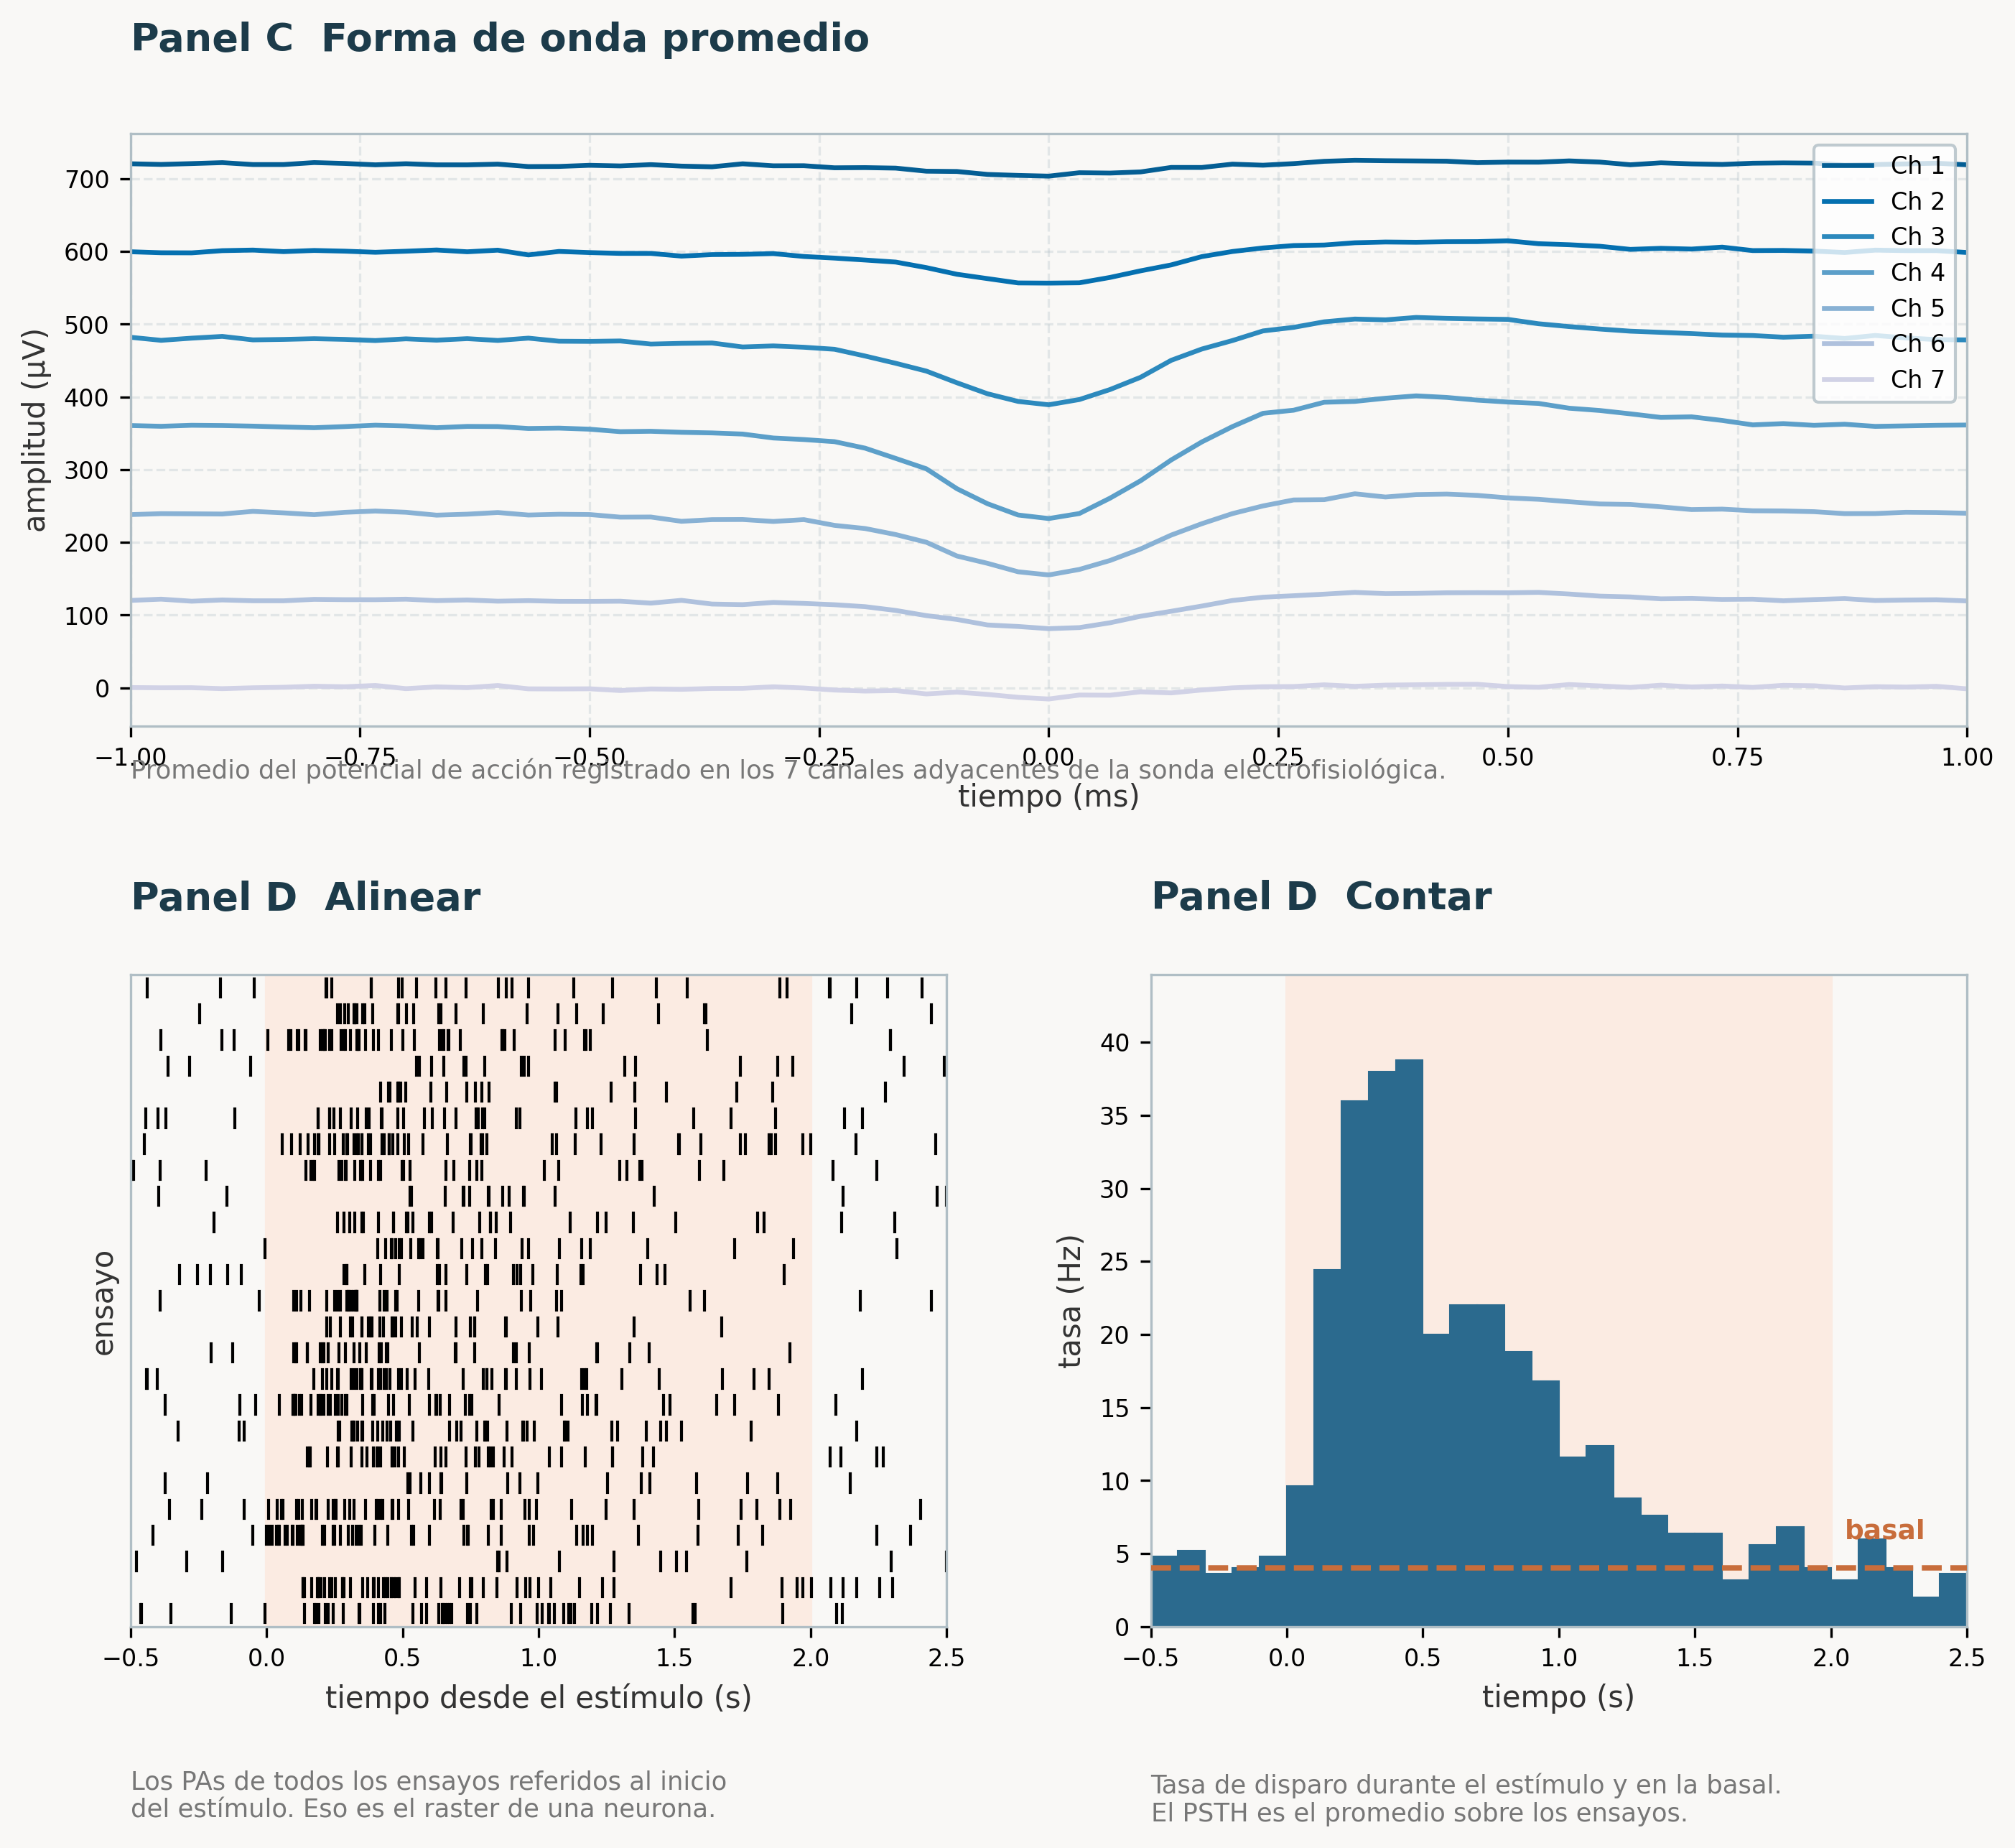

In [29]:
import logging
import matplotlib.font_manager as fm
import matplotlib.gridspec as gridspec
import matplotlib.pyplot as plt
import numpy as np

# 1. EVITAR ADVERTENCIAS DE FUENTES Y CONFIGURAR MULTIPLATAFORMA
logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.sans-serif"] = [
    "DejaVu Sans",
    "Arial",
    "Helvetica",
    "Liberation Sans",
]

# Semilla para reproducibilidad
np.random.seed(42)

# ============================================================
# 1. SIMULACIÓN DE DATOS
# ============================================================
n_ensayos = 25
t_inicio, t_fin = -0.5, 2.5
dur_est = 2.0  # Duración del estímulo (0.0 a 2.0 s)

# A) Forma de onda promedio en 7 canales (Panel C)
n_canales = 7
n_muestras = 61
t_onda = np.linspace(-1.0, 1.0, n_muestras)
atenuacion = np.array([0.12, 0.35, 0.70, 1.00, 0.65, 0.30, 0.10])
forma_base = (
    -130 * np.exp(-((t_onda - 0.0) / 0.15) ** 2)
    + 40 * np.exp(-((t_onda - 0.4) / 0.25) ** 2)
    - 12 * np.exp(-((t_onda + 0.3) / 0.2) ** 2)
)

u_onda = np.zeros((n_canales, n_muestras))
for ch in range(n_canales):
    ruido = np.random.normal(0, 1.5, n_muestras)
    u_onda[ch, :] = forma_base * atenuacion[ch] + ruido

# B) Proceso de Poisson para Spikes (Panel D)
spikes_t = []
spikes_e = []

for e in range(n_ensayos):
    t_curr = t_inicio
    while t_curr < t_fin:
        if 0.0 <= t_curr < 0.1:
            rate = 45.0
        elif 0.1 <= t_curr < 0.2:
            rate = 65.0
        elif 0.2 <= t_curr < 0.35:
            rate = 52.0
        elif 0.35 <= t_curr < 0.5:
            rate = 38.0
        elif 0.5 <= t_curr < 0.65:
            rate = 22.0
        elif 0.65 <= t_curr < 0.95:
            rate = 18.0
        elif 0.95 <= t_curr < 1.3:
            rate = 10.0
        elif 1.3 <= t_curr < 2.0:
            rate = 5.0
        else:
            rate = 4.0

        dt = np.random.exponential(1.0 / rate)
        t_curr += dt
        if t_curr < t_fin:
            spikes_t.append(t_curr)
            spikes_e.append(e)

spikes_t = np.array(spikes_t)
spikes_e = np.array(spikes_e)

# ============================================================
# 2. DISPOSICIÓN DE PANELES (GRIDSPEC: ARRIBA Y ABAJO)
# ============================================================
fig = plt.figure(figsize=(11, 9), dpi=300)
fig.patch.set_facecolor("#f9f8f6")  # Fondo beige claro

# Gridspec con 2 filas
gs = gridspec.GridSpec(2, 2, height_ratios=[1, 1.1], hspace=0.4, wspace=0.25)

# Panel C ocupa arriba (centrado en la cuadrícula superior)
ax_c = fig.add_subplot(gs[0, :])

# Panel D ocupa las dos columnas inferiores
ax_raster = fig.add_subplot(gs[1, 0])
ax_psth = fig.add_subplot(gs[1, 1])

# Estilos de color
color_sombreo = "#fbebe2"
color_barras = "#2b6a8e"
color_basal = "#c86d3b"

# ------------------------------------------------------------
# PANEL C: Forma de onda promedio
# ------------------------------------------------------------
ax_c.set_facecolor("#f9f8f6")
colores_canales = plt.cm.PuBu_r(np.linspace(0.15, 0.75, n_canales))
offset = 120.0

for ch in range(n_canales):
    desplazamiento = (n_canales - 1 - ch) * offset
    ax_c.plot(
        t_onda,
        u_onda[ch, :] + desplazamiento,
        color=colores_canales[ch],
        linewidth=1.6,
        label=f"Ch {ch+1}",
    )

ax_c.set_xlim(-1.0, 1.0)
ax_c.set_xlabel("tiempo (ms)", fontsize=10, color="#333333")
ax_c.set_ylabel("amplitud (µV)", fontsize=10, color="#333333")
ax_c.text(
    -1.0,
    (n_canales + 0.3) * offset,
    "Panel C  Forma de onda promedio",
    fontsize=13,
    fontweight="bold",
    color="#1c3b4a",
)
ax_c.text(
    -1.0,
    -offset * 0.8,
    "Promedio del potencial de acción registrado en los 7 canales adyacentes de la sonda electrofisiológica.",
    fontsize=8.5,
    color="#777777",
    va="top",
)
ax_c.grid(True, linestyle="--", alpha=0.3, color="#b0bec5")
ax_c.legend(
    loc="upper right",
    fontsize=8,
    frameon=True,
    facecolor="#ffffff",
    edgecolor="#b0bec5",
)

# ------------------------------------------------------------
# PANEL D (Izquierda): Raster Plot ("Alinear")
# ------------------------------------------------------------
ax_raster.set_facecolor("#f9f8f6")
ax_raster.axvspan(0.0, dur_est, color=color_sombreo, zorder=0)

for t_val, e_val in zip(spikes_t, spikes_e):
    ax_raster.plot(
        [t_val, t_val], [e_val + 0.15, e_val + 0.85], color="black", linewidth=1.0
    )

ax_raster.set_xlim(t_inicio, t_fin)
ax_raster.set_ylim(0, n_ensayos)
ax_raster.set_xlabel(
    "tiempo desde el estímulo (s)", fontsize=10, color="#333333"
)
ax_raster.set_ylabel("ensayo", fontsize=10, color="#333333")
ax_raster.set_yticks([])
ax_raster.text(
    -0.5,
    n_ensayos + 2.5,
    "Panel D  Alinear",
    fontsize=13,
    fontweight="bold",
    color="#1c3b4a",
)
ax_raster.text(
    -0.5,
    -5.5,
    "Los PAs de todos los ensayos referidos al inicio\ndel estímulo. Eso es el raster de una neurona.",
    fontsize=8.5,
    color="#777777",
    va="top",
)

# ------------------------------------------------------------
# PANEL D (Derecha): PSTH ("Contar")
# ------------------------------------------------------------
ax_psth.set_facecolor("#f9f8f6")
ax_psth.axvspan(0.0, dur_est, color=color_sombreo, zorder=0)

bin_width = 0.1
bins = np.arange(t_inicio, t_fin + bin_width, bin_width)
counts, _ = np.histogram(spikes_t, bins=bins)
tasas = counts / (n_ensayos * bin_width)

ax_psth.bar(
    bins[:-1],
    tasas,
    width=bin_width,
    align="edge",
    color=color_barras,
    edgecolor=color_barras,
    linewidth=0.5,
    zorder=2,
)

tasa_basal_media = 4.0
ax_psth.axhline(
    y=tasa_basal_media, color=color_basal, linestyle="--", linewidth=1.8, zorder=3
)
ax_psth.text(
    2.05,
    tasa_basal_media + 2.0,
    "basal",
    color=color_basal,
    fontweight="bold",
    fontsize=9,
)

ax_psth.set_xlim(t_inicio, t_fin)
ax_psth.set_ylim(0, max(tasas) * 1.15)
ax_psth.set_xlabel("tiempo (s)", fontsize=10, color="#333333")
ax_psth.set_ylabel("tasa (Hz)", fontsize=10, color="#333333")
ax_psth.text(
    -0.5,
    max(tasas) * 1.15 + 4.5,
    "Panel D  Contar",
    fontsize=13,
    fontweight="bold",
    color="#1c3b4a",
)
ax_psth.text(
    -0.5,
    -10.0,
    "Tasa de disparo durante el estímulo y en la basal.\nEl PSTH es el promedio sobre los ensayos.",
    fontsize=8.5,
    color="#777777",
    va="top",
)

# --- Ajuste de bordes para todos los ejes ---
for ax in [ax_c, ax_raster, ax_psth]:
    for spine in ax.spines.values():
        spine.set_color("#b0bec5")
        spine.set_linewidth(0.8)

plt.savefig(
    "panel_c_y_d_vertical.png",
    dpi=300,
    facecolor=fig.get_facecolor(),
    bbox_inches="tight",
)
plt.show()